# Stock Market Analysis and Prediction using CAPM

## Project Overview
This project involves analyzing stock prices and market index data to make informed investment decisions using financial models like the Capital Asset Pricing Model (CAPM) and beta calculations. The objectives include:

- Calculating the beta values for selected stocks.
- Determining expected returns using the CAPM.
- Normalizing stock prices to visualize their performance over time.
- Calculating the portfolio beta and expected return.
- Visualizing relationships and trends.
- Using basic machine learning models to predict future portfolio values.

Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from google.colab import auth
from google.cloud import bigquery

# Authenticate with Google Cloud
auth.authenticate_user()
print('Authenticated')


Authenticated


Data Cleaning, Processing and Calculating daily returns


In [ ]:
# Query the BigQuery to retrieve data
client = bigquery.Client(project='risks-and-returrns-stocks')
data = client.query('''SELECT * FROM `risks-and-returrns-stocks.stocks_shares_csv.10yr_data`''').to_dataframe()

# Define stocks to analyze
stocks = ['AAPL', 'NFLX', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'GOOG']

# Calculate daily returns for each stock and the market index (S&P 500)
for stock in stocks:
    data[f'{stock}_Return'] = data[stock].pct_change()

# Calculate daily returns for the market index
data['SP500_Return'] = data['SP500'].pct_change()

# Drop rows with NaN values resulting from percentage change calculation
data.dropna(inplace=True)

# Display the processed data
data.head()

,DATE,AAPL,NFLX,BA,T,MGM,AMZN,IBM,GOOG,SP500,AAPL_Return,NFLX_Return,BA_Return,T_Return,MGM_Return,AMZN_Return,IBM_Return,GOOG_Return,SP500_Return
1,2014-10-20,24.94,51.32,124.31,25.87,21.70,15.31,161.52,25.97,1904.01,0.021294,0.006077,0.008682,0.005832,-0.000461,0.008564,-0.071137,0.018831,0.009143
2,2014-10-21,25.62,52.28,127.12,26.13,22.45,15.77,155.91,26.26,1941.28,0.027265,0.018706,0.022605,0.010050,0.034562,0.030046,-0.034733,0.011167,0.019574
3,2014-10-22,25.75,53.52,121.45,26.04,22.12,15.65,154.54,26.56,1927.11,0.005074,0.023718,-0.044604,-0.003444,-0.014699,-0.007609,-0.008787,0.011424,-0.007299
4,2014-10-23,26.21,54.72,122.03,25.41,22.36,15.66,154.91,27.13,1950.82,0.017864,0.022422,0.004776,-0.024194,0.010850,0.000639,0.002394,0.021461,0.012303
5,2014-10-24,26.31,55.00,122.24,25.56,22.58,14.35,154.81,26.92,1964.58,0.003815,0.005117,0.001721,0.005903,0.009839,-0.083653,-0.000646,-0.007741,0.007053


In [ ]:
df_melted = pd.melt(data[["DATE","AAPL", "NFLX", "BA",  "T",  "MGM", "AMZN" , "IBM", "GOOG", "SP500"]], id_vars=['DATE'], var_name='Stock', value_name='Price')

In [ ]:
df_melted

,DATE,Stock,Price
0,2014-10-20,AAPL,24.94
1,2014-10-21,AAPL,25.62
2,2014-10-22,AAPL,25.75
3,2014-10-23,AAPL,26.21
4,2014-10-24,AAPL,26.31
...,...,...,...
22612,2024-10-08,SP500,5751.13
22613,2024-10-09,SP500,5792.04
22614,2024-10-10,SP500,5780.05
22615,2024-10-11,SP500,5815.03


In [ ]:
df_melted_return = pd.melt(data[["DATE","AAPL_Return", "NFLX_Return", "BA_Return",  "T_Return",  "MGM_Return", "AMZN_Return" , "IBM_Return", "GOOG_Return", "SP500_Return"]], id_vars=['DATE'], var_name='Stock', value_name='Return')

In [ ]:
df_melted_return

,DATE,Stock,Return
0,2014-10-20,AAPL_Return,0.021294
1,2014-10-21,AAPL_Return,0.027265
2,2014-10-22,AAPL_Return,0.005074
3,2014-10-23,AAPL_Return,0.017864
4,2014-10-24,AAPL_Return,0.003815
...,...,...,...
22612,2024-10-08,SP500_Return,0.009689
22613,2024-10-09,SP500_Return,0.007113
22614,2024-10-10,SP500_Return,-0.002070
22615,2024-10-11,SP500_Return,0.006052


In [ ]:
df_melted_return['Stock'].str.replace("_Return","")

,Stock
0,AAPL
1,AAPL
2,AAPL
3,AAPL
4,AAPL
...,...
22612,SP500
22613,SP500
22614,SP500
22615,SP500


In [ ]:
df_melted_return['Stock']= df_melted_return['Stock'].str.replace("_Return","")

In [ ]:
df_melted_return

,DATE,Stock,Return
0,2014-10-20,AAPL,0.021294
1,2014-10-21,AAPL,0.027265
2,2014-10-22,AAPL,0.005074
3,2014-10-23,AAPL,0.017864
4,2014-10-24,AAPL,0.003815
...,...,...,...
22612,2024-10-08,SP500,0.009689
22613,2024-10-09,SP500,0.007113
22614,2024-10-10,SP500,-0.002070
22615,2024-10-11,SP500,0.006052


In [ ]:
Melted_data = df_melted.merge(df_melted_return, on=['DATE','Stock'])

In [ ]:
Melted_data

,DATE,Stock,Price,Return
0,2014-10-20,AAPL,24.94,0.021294
1,2014-10-21,AAPL,25.62,0.027265
2,2014-10-22,AAPL,25.75,0.005074
3,2014-10-23,AAPL,26.21,0.017864
4,2014-10-24,AAPL,26.31,0.003815
...,...,...,...,...
22612,2024-10-08,SP500,5751.13,0.009689
22613,2024-10-09,SP500,5792.04,0.007113
22614,2024-10-10,SP500,5780.05,-0.002070
22615,2024-10-11,SP500,5815.03,0.006052


In [ ]:
import pandas_gbq
import pandas


df_to_bq = return_data
dataset_name = 'stocks_shares_csv'
table_name = 'cleaned_stock_return'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

In [ ]:
from google.cloud import bigquery
import pandas as pd

# Query the BigQuery to retrieve data
client = bigquery.Client(project='risks-and-returrns-stocks')
data = client.query('''SELECT * FROM `risks-and-returrns-stocks.stocks_shares_csv.10yr_data`''').to_dataframe()

# Define stocks to analyze
stocks = ['AAPL', 'NFLX', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'GOOG']

# Calculate daily returns for each stock and the market index (S&P 500)
for stock in stocks:
    data[f'{stock}_Return'] = data[stock].pct_change()

# Calculate daily returns for the market index
data['SP500_Return'] = data['SP500'].pct_change()

# Drop rows with NaN values resulting from percentage change calculation
data.dropna(inplace=True)


In [ ]:

# Create a DataFrame for returns
return_columns = ['DATE'] + [f'{stock}_Return' for stock in stocks] + ['SP500_Return']  # Include date and returns
return_data = data[return_columns]


print("\nReturn Data:")
print(return_data.head())



Return Data:
         DATE  AAPL_Return  NFLX_Return  BA_Return  T_Return  MGM_Return  \
1  2014-10-20     0.021294     0.006077   0.008682  0.005832   -0.000461   
2  2014-10-21     0.027265     0.018706   0.022605  0.010050    0.034562   
3  2014-10-22     0.005074     0.023718  -0.044604 -0.003444   -0.014699   
4  2014-10-23     0.017864     0.022422   0.004776 -0.024194    0.010850   
5  2014-10-24     0.003815     0.005117   0.001721  0.005903    0.009839   

   AMZN_Return  IBM_Return  GOOG_Return  SP500_Return  
1     0.008564   -0.071137     0.018831      0.009143  
2     0.030046   -0.034733     0.011167      0.019574  
3    -0.007609   -0.008787     0.011424     -0.007299  
4     0.000639    0.002394     0.021461      0.012303  
5    -0.083653   -0.000646    -0.007741      0.007053  


In [ ]:
import pandas
import pandas_gbq

df_to_bq = return_data
dataset_name = 'stocks_shares_csv'
table_name = 'cleaned_stock_return'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

TableCreationError: Reason: Already Exists: Table risks-and-returrns-stocks:stocks_shares_csv.cleaned_stock_return

In [ ]:
#Normalised prices

import pandas as pd

# Assuming 'data' is the DataFrame you have

# Copy the original DataFrame
normalized_data = data.copy()

# Get the first row (initial prices) and set it as a divisor
initial_prices = data.iloc[0, 1:]  # Skip the 'DATE' column

# Normalize by dividing each stock column by the initial price
normalized_data.iloc[:, 1:] = data.iloc[:, 1:].div(initial_prices)

normalized_data



<ipython-input-3-292973787ea2>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1            1.0
2       1.027265
3       1.032478
4       1.050922
5       1.054932
          ...   
2509    9.052526
2510    9.203689
2511    9.183641
2512    9.123897
2513    9.274258
Name: AAPL, Length: 2513, dtype: object' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  normalized_data.iloc[:, 1:] = data.iloc[:, 1:].div(initial_prices)
<ipython-input-3-292973787ea2>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1             1.0
2        1.018706
3        1.042868
4        1.066251
5        1.071707
          ...    
2509    14.063913
2510    14.174396
2511    14.230125
2512    14.083983
2513    13.893219
Name: NFLX, Length: 2513, dtype: object' has dtype incompatible with float64, please explicitly cast to a comp

,DATE,AAPL,NFLX,BA,T,MGM,AMZN,IBM,GOOG,SP500,AAPL_Return,NFLX_Return,BA_Return,T_Return,MGM_Return,AMZN_Return,IBM_Return,GOOG_Return,SP500_Return
1,2014-10-20,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,2014-10-21,1.027265,1.018706,1.022605,1.01005,1.034562,1.030046,0.965267,1.011167,1.019574,1.280427,3.078068,2.603563,1.723283,-75.034562,3.508416,0.488249,0.593,2.141005
3,2014-10-22,1.032478,1.042868,0.976993,1.006571,1.019355,1.022208,0.956786,1.022719,1.012132,0.23829,3.902831,-5.137326,-0.590586,31.912249,-0.888542,0.123524,0.606674,-0.798379
4,2014-10-23,1.050922,1.066251,0.981659,0.982219,1.030415,1.022861,0.959076,1.044667,1.024585,0.838925,3.689426,0.550045,-4.148387,-23.555154,0.074613,-0.033656,1.13966,1.345714
5,2014-10-24,1.054932,1.071707,0.983348,0.988017,1.040553,0.937296,0.958457,1.036581,1.031812,0.179174,0.841987,0.198208,1.0122,-21.360465,-9.768052,0.009075,-0.411053,0.771487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,2024-10-08,9.052526,14.063913,1.244067,0.844994,1.834562,11.934683,1.415428,6.380439,3.020536,0.864284,4.651014,-0.930817,0.629813,68.140876,1.240027,-0.092841,0.423179,1.059797
2510,2024-10-09,9.203689,14.174396,1.201593,0.8477,1.851613,12.094709,1.450594,6.278783,3.042022,0.784183,1.292659,-3.932348,0.54907,-20.177594,1.5657,-0.349252,-0.846077,0.778043
2511,2024-10-10,9.183641,14.230125,1.179471,0.820255,1.824424,12.191378,1.44267,6.283404,3.035725,-0.102295,0.646947,-2.120495,-5.55136,31.878795,0.933296,0.076797,0.039081,-0.22642
2512,2024-10-11,9.123897,14.083983,1.214866,0.826053,1.82765,12.333116,1.444156,6.335002,3.054096,-0.305504,-1.689894,3.456427,1.212064,-3.838596,1.357564,-0.014478,0.43608,0.661936


In [ ]:
normalized_data[['AAPL','NFLX','BA','T','MGM','AMZN',	'IBM',	'GOOG',	'SP500'	,'AAPL_Return',	'NFLX_Return',	'BA_Return',	'T_Return',	'MGM_Return',	'AMZN_Return',	'IBM_Return',	'GOOG_Return',	'SP500_Return']]= normalized_data[['AAPL','NFLX','BA','T','MGM','AMZN',	'IBM',	'GOOG',	'SP500'	,'AAPL_Return',	'NFLX_Return',	'BA_Return',	'T_Return',	'MGM_Return',	'AMZN_Return',	'IBM_Return',	'GOOG_Return',	'SP500_Return']].astype(float)

NameError: name 'normalized_data' is not defined

In [ ]:
df_normalised_melt = pd.melt(normalized_data[["DATE","AAPL", "NFLX", "BA",  "T",  "MGM", "AMZN" , "IBM", "GOOG", "SP500"]], id_vars=['DATE'], var_name='Stock', value_name='Normalised_price')

In [ ]:
df_normalised_melt

,DATE,Stock,Normalised_price
0,2014-10-20,AAPL,1.000000
1,2014-10-21,AAPL,1.027265
2,2014-10-22,AAPL,1.032478
3,2014-10-23,AAPL,1.050922
4,2014-10-24,AAPL,1.054932
...,...,...,...
22612,2024-10-08,SP500,3.020536
22613,2024-10-09,SP500,3.042022
22614,2024-10-10,SP500,3.035725
22615,2024-10-11,SP500,3.054096


In [ ]:
Melted_all = df_normalised_melt.merge(Melted_data, on=['DATE','Stock'])

In [ ]:
import pandas_gbq
df_to_bq = Melted_all
dataset_name = 'stocks_shares_csv'
table_name = 'Joined_Melted_data'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

100%|██████████| 1/1 [00:00<00:00, 499.80it/s]


In [ ]:
normalized_data

,DATE,AAPL,NFLX,BA,T,MGM,AMZN,IBM,GOOG,SP500,AAPL_Return,NFLX_Return,BA_Return,T_Return,MGM_Return,AMZN_Return,IBM_Return,GOOG_Return,SP500_Return
1,2014-10-20,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,2014-10-21,1.027265,1.018706,1.022605,1.010050,1.034562,1.030046,0.965267,1.011167,1.019574,1.280427,3.078068,2.603563,1.723283,-75.034562,3.508416,0.488249,0.593000,2.141005
3,2014-10-22,1.032478,1.042868,0.976993,1.006571,1.019355,1.022208,0.956786,1.022719,1.012132,0.238290,3.902831,-5.137326,-0.590586,31.912249,-0.888542,0.123524,0.606674,-0.798379
4,2014-10-23,1.050922,1.066251,0.981659,0.982219,1.030415,1.022861,0.959076,1.044667,1.024585,0.838925,3.689426,0.550045,-4.148387,-23.555154,0.074613,-0.033656,1.139660,1.345714
5,2014-10-24,1.054932,1.071707,0.983348,0.988017,1.040553,0.937296,0.958457,1.036581,1.031812,0.179174,0.841987,0.198208,1.012200,-21.360465,-9.768052,0.009075,-0.411053,0.771487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,2024-10-08,9.052526,14.063913,1.244067,0.844994,1.834562,11.934683,1.415428,6.380439,3.020536,0.864284,4.651014,-0.930817,0.629813,68.140876,1.240027,-0.092841,0.423179,1.059797
2510,2024-10-09,9.203689,14.174396,1.201593,0.847700,1.851613,12.094709,1.450594,6.278783,3.042022,0.784183,1.292659,-3.932348,0.549070,-20.177594,1.565700,-0.349252,-0.846077,0.778043
2511,2024-10-10,9.183641,14.230125,1.179471,0.820255,1.824424,12.191378,1.442670,6.283404,3.035725,-0.102295,0.646947,-2.120495,-5.551360,31.878795,0.933296,0.076797,0.039081,-0.226420
2512,2024-10-11,9.123897,14.083983,1.214866,0.826053,1.827650,12.333116,1.444156,6.335002,3.054096,-0.305504,-1.689894,3.456427,1.212064,-3.838596,1.357564,-0.014478,0.436080,0.661936


In [ ]:
normalized_data.dtypes

,0
DATE,dbdate
AAPL,float64
NFLX,float64
BA,float64
T,float64
MGM,float64
AMZN,float64
IBM,float64
GOOG,float64
SP500,float64


In [ ]:
df_to_bq = normalized_data
dataset_name = 'stocks_shares_csv'
table_name = 'normalised_data'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

TableCreationError: Reason: Already Exists: Table risks-and-returrns-stocks:stocks_shares_csv.normalised_data

Visualization - Stock Return Distributions

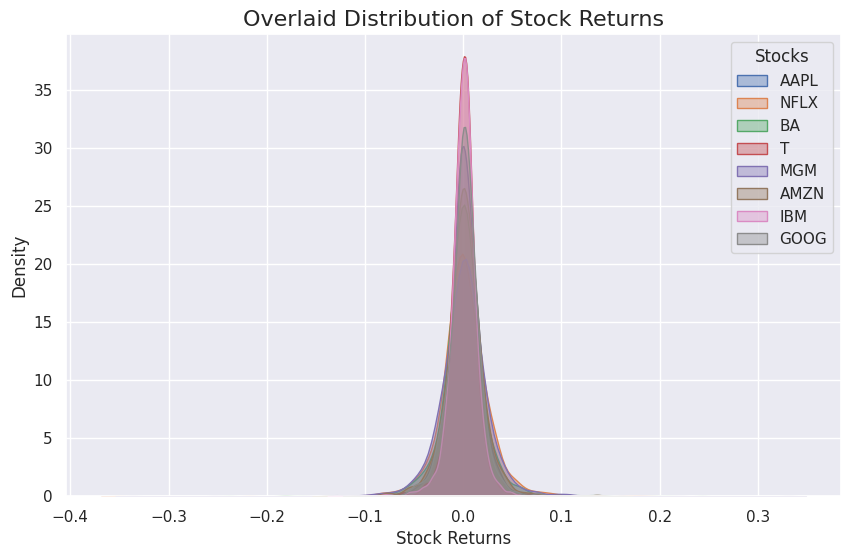

In [ ]:
# Set up the plotting style
sns.set(style="darkgrid")

# Initialize the plot
plt.figure(figsize=(10, 6))
plt.title("Overlaid Distribution of Stock Returns", fontsize=16)

# Loop through the list of stocks and plot each stock's returns
for stock in stocks:
    stock_return_col = f'{stock}_Return'
    sns.kdeplot(data[stock_return_col], label=stock, fill=True, alpha=0.4)

# Add labels and legend
plt.xlabel('Stock Returns')
plt.ylabel('Density')
plt.legend(title="Stocks")
plt.show()

CAPM Analysis - Calculating Beta

Theory Behind Beta

Beta measures the volatility or risk of a stock in relation to the market:
A beta of 1 indicates that the stock moves with the market.
A beta greater than 1 indicates greater volatility than the market
A beta less than 1 indicates less volatility.

Using linear regression, we can estimate beta for each stock relative to the market:

In [ ]:
# Function to calculate beta using linear regression
def calculate_beta(stock_returns, market_returns):
    X = sm.add_constant(market_returns)  # Add a constant term (intercept)
    model = sm.OLS(stock_returns, X).fit()
    return model.params.iloc[1]  # Beta is the slope coefficient

# Calculate beta for each stock
beta_values = {}
market_returns = data['SP500_Return']

for stock in stocks:
    stock_returns = data[f'{stock}_Return']
    beta_values[stock] = calculate_beta(stock_returns, market_returns)

# Create a DataFrame to store the beta values
beta_df = pd.DataFrame(list(beta_values.items()), columns=['Stock', 'Beta'])
beta_df = beta_df.sort_values(by='Beta', ascending=False)

# Display the beta values
print(beta_df)


  Stock      Beta
4   MGM  1.577152
2    BA  1.361690
0  AAPL  1.199963
1  NFLX  1.169000
7  GOOG  1.142078
5  AMZN  1.138423
6   IBM  0.838655
3     T  0.621972


In [ ]:
df_to_bq = beta_df
dataset_name = 'stocks_shares_csv'
table_name = 'beta_data'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

Expected Return Calculation using CAPM

CAPM and Expected Returns Theory Behind CAPM The Capital Asset Pricing Model (CAPM) calculates the expected return of an asset based on its beta and the expected market return. The formula is: 𝐸 ( 𝑅 𝑖 ) = 𝑅 𝑓 + 𝛽 𝑖 ( 𝐸 ( 𝑅 𝑚 ) − 𝑅 𝑓 ) E(R i​)=R f​+β i​(E(R m​)−R f​) Where:

𝐸 ( 𝑅 𝑖 ) E(R i​) = expected return of the investment 𝑅 𝑓 R f​= risk-free rate 𝛽 𝑖 β i​= beta of the investment 𝐸 ( 𝑅 𝑚 ) E(R m​) = expected return of the market

In [ ]:
# Assumptions
risk_free_rate = 0.0409  # Assume 4.09% as the risk-free rate

# Calculate the average market return (S&P 500) over the entire dataset
market_avg_return = data['SP500_Return'].mean()*252

# Initialize an empty list to store stock beta, CAPM expected return, and the average stock return
stock_data = []

# Iterate through each stock to calculate its CAPM and average return
for stock in stocks:
    beta = beta_values[stock]
    capm_expected_return = risk_free_rate + beta * (market_avg_return - risk_free_rate)
    avg_stock_return = data[f'{stock}_Return'].mean()

    stock_data.append({
        'Stock': stock,
        'Beta': beta,
        'CAPM_Expected_Return': capm_expected_return,
        'Avg_Stock_Return': avg_stock_return
    })

# Convert the list of stock data into a DataFrame
stock_selection_df = pd.DataFrame(stock_data)

# Sort the DataFrame by CAPM Expected Return in descending order
stock_selection_df = stock_selection_df.sort_values(by='CAPM_Expected_Return', ascending=False)

# Display the DataFrame
print(stock_selection_df)

  Stock      Beta  CAPM_Expected_Return  Avg_Stock_Return
4   MGM  1.577152              0.180823          0.000654
2    BA  1.361690              0.161708          0.000396
0  AAPL  1.199963              0.147360          0.001057
1  NFLX  1.169000              0.144613          0.001432
7  GOOG  1.142078              0.142224          0.000905
5  AMZN  1.138423              0.141900          0.001213
6   IBM  0.838655              0.115305          0.000234
3     T  0.621972              0.096081          0.000028


In [ ]:
df_to_bq = stock_selection_df
dataset_name = 'stocks_shares_csv'
table_name = 'stock_selection'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Sample data as provided
data = {
    'Stock': ['T', 'IBM', 'BA', 'MGM', 'GOOG', 'AMZN', 'NFLX', 'AAPL'],
    'Beta': [-0.267144, 0.125730, 0.640954, 0.808691, 1.939271, 2.404337, 2.575098, 3.199531],
    'CAPM_Expected_Return': [0.042443, 0.040174, 0.037197, 0.036228, 0.029697, 0.027010, 0.026023, 0.022416],
    'Avg_Stock_Return': [0.008835, 0.014174, 0.098515, 0.050706, 0.112401, 0.217483, 0.262578, 0.213499]
}

# Create a DataFrame from the data
stock_selection_df = pd.DataFrame(data)

# Create a grouped bar plot
fig = go.Figure()

# Add bars for CAPM Expected Return
fig.add_trace(go.Bar(
    x=stock_selection_df['Stock'],
    y=stock_selection_df['CAPM_Expected_Return'],
    name='CAPM Expected Return',
    marker_color='royalblue'
))

# Add bars for Average Stock Return
fig.add_trace(go.Bar(
    x=stock_selection_df['Stock'],
    y=stock_selection_df['Avg_Stock_Return'],
    name='Average Stock Return',
    marker_color='orange'
))

# Add bars for Beta
fig.add_trace(go.Bar(
    x=stock_selection_df['Stock'],
    y=stock_selection_df['Beta'],
    name='Beta',
    marker_color='firebrick'
))

# Update layout
fig.update_layout(
    title='Comparison of CAPM Expected Return, Average Return, and Beta of Stocks',
    xaxis_title='Stocks',
    yaxis_title='Returns & Beta',
    barmode='group',  # Group bars together
    template='plotly_dark'
)

# Show the figure
fig.show()

## ****** bold text

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sample data
data = {
    'Stock': ['T', 'IBM', 'BA', 'MGM', 'GOOG', 'AMZN', 'NFLX', 'AAPL'],
    'Beta': [-0.267144, 0.125730, 0.640954, 0.808691, 1.939271, 2.404337, 2.575098, 3.199531],
    'CAPM_Expected_Return': [0.042443, 0.040174, 0.037197, 0.036228, 0.029697, 0.027010, 0.026023, 0.022416],
    'Avg_Stock_Return': [0.008835, 0.014174, 0.098515, 0.050706, 0.112401, 0.217483, 0.262578, 0.213499]
}

# Create a DataFrame from the data
stock_selection_df = pd.DataFrame(data)

# Create a subplot with a secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add bars for CAPM Expected Return
fig.add_trace(go.Bar(
    x=stock_selection_df['Stock'],
    y=stock_selection_df['CAPM_Expected_Return'],
    name='CAPM Expected Return',
    marker_color='royalblue'
), secondary_y=False)

# Add bars for Average Stock Return
fig.add_trace(go.Bar(
    x=stock_selection_df['Stock'],
    y=stock_selection_df['Avg_Stock_Return'],
    name='Average Stock Return',
    marker_color='orange'
), secondary_y=False)

# Add bars for Beta (secondary y-axis)
fig.add_trace(go.Scatter(
    x=stock_selection_df['Stock'],
    y=stock_selection_df['Beta'],
    name='Beta',
    mode='lines+markers',
    line=dict(color='firebrick', width=3),
    marker=dict(size=8)
), secondary_y=True)

# Update layout with titles and axis labels
fig.update_layout(
    title='Comparison of CAPM Expected Return, Average Return, and Beta of Stocks',
    xaxis_title='Stocks',
    template='plotly_dark',
    legend=dict(x=0.8, y=1.1)
)

# Set y-axis titles
fig.update_yaxes(title_text="Returns", secondary_y=False)
fig.update_yaxes(title_text="Beta", secondary_y=True)

# Show the figure
fig.show()




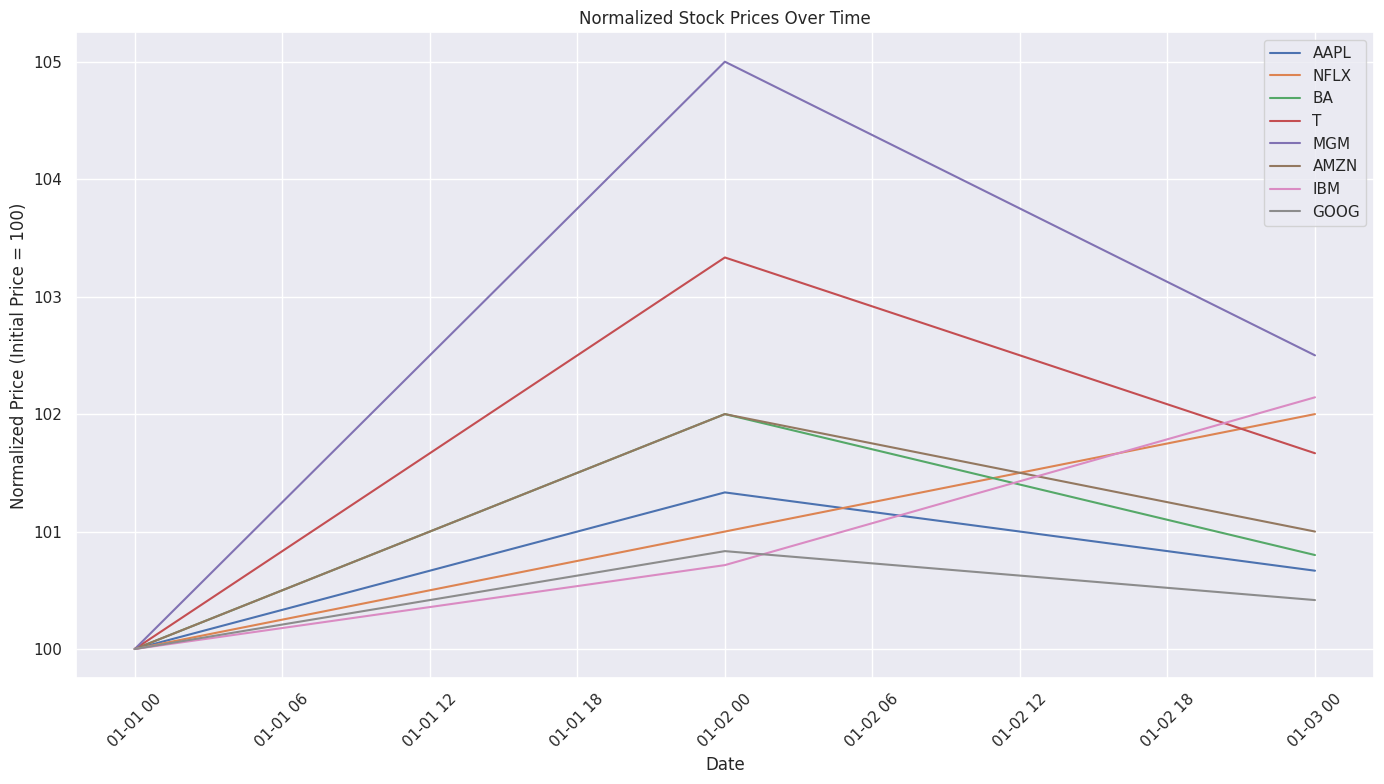

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data dictionary (replace this with your actual data)
data = {
    'DATE': ['2024-01-01', '2024-01-02', '2024-01-03'],
    'AAPL': [150, 152, 151],
    'NFLX': [200, 202, 204],
    'BA': [250, 255, 252],
    'T': [30, 31, 30.5],
    'MGM': [40, 42, 41],
    'AMZN': [100, 102, 101],
    'IBM': [140, 141, 143],
    'GOOG': [1200, 1210, 1205]
}

# Convert the dictionary to a DataFrame
data = pd.DataFrame(data)

# Convert the 'DATE' column to datetime format
data['DATE'] = pd.to_datetime(data['DATE'])

# Function to normalize the prices based on the initial price
def normalize(df):
    x = df.copy()
    for col in x.columns[1:]:  # Assuming the first column is a date or non-stock column
        x[col] = x[col] / x[col].iloc[0] * 100  # Normalize to the first value and multiply by 100 for percentage scale
    return x

# Define the list of stocks
stocks = ['AAPL', 'NFLX', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'GOOG']

# Normalize stock prices over time
normalized_prices = normalize(data[['DATE'] + stocks])  # Correctly subsetting the DataFrame

# Plot normalized stock prices
plt.figure(figsize=(14, 8))
for stock in stocks:
    plt.plot(normalized_prices['DATE'], normalized_prices[stock], label=stock)  # Plot each stock's normalized price

# Plot customization
plt.title('Normalized Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Initial Price = 100)')
plt.legend(stocks)
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

# Simulate sample data for the specified date range
np.random.seed(42)  # For reproducibility
# Create a date range from October 17, 2014, to October 14, 2024, with daily frequency
dates = pd.date_range(start="2014-10-17", end="2024-10-14", freq='D')

# Create a DataFrame with simulated stock prices
data = pd.DataFrame({
    "DATE": dates,
    "AAPL": np.random.uniform(low=22.59, high=234.82, size=len(dates)),
    "NFLX": np.random.uniform(low=45.21, high=730.29, size=len(dates)),
    "BA": np.random.uniform(low=95.1, high=440.62, size=len(dates)),
    "T": np.random.uniform(low=13.45, high=32.81, size=len(dates)),
    "MGM": np.random.uniform(low=7.14, high=50.90, size=len(dates)),
    "AMZN": np.random.uniform(low=14.35, high=200, size=len(dates)),
    "IBM": np.random.uniform(low=90.52, high=235.26, size=len(dates)),
    "GOOG": np.random.uniform(low=24.56, high=192.66, size=len(dates)),
    "SP500": np.random.uniform(low=1829.08, high=5859.85, size=len(dates))
})

# Ensure 'DATE' is in the correct format
data['DATE'] = pd.to_datetime(data['DATE'])

# List of stock columns to normalize
stocks = ["AAPL", "NFLX", "BA", "T", "MGM", "AMZN", "IBM", "GOOG", "SP500"]

# Normalize the prices by subtracting the minimum price for each stock
normalized_prices = data[stocks].subtract(data[stocks].min()).clip(lower=0)
normalized_prices['DATE'] = data['DATE']  # Add date column back for plotting

# Resample the normalized prices to yearly frequency, taking the last available price for each year
yearly_normalized_prices = normalized_prices.set_index('DATE').resample('Y').last().reset_index()

# Melt the DataFrame for Plotly Express
yearly_normalized_prices_melted = yearly_normalized_prices.melt(id_vars='DATE', var_name='Stock', value_name='Normalized Price')

# Plot normalized stock prices over time using Plotly Express
fig = px.line(yearly_normalized_prices_melted, x='DATE', y='Normalized Price', color='Stock',
              title='Normalized Stock Prices Over Time (Yearly)',
              labels={'Normalized Price': 'Price', 'Stock': 'Stocks'},
              template='plotly_dark')

# Update layout
fig.update_layout(xaxis_title='Date', yaxis_title='Normalized Price')

# Show the interactive figure
fig.show()










<ipython-input-13-2afe3f343172>:35: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



In [ ]:
import pandas as pd
import plotly.express as px

# Load your actual stock data from the CSV file
data = pd.read_csv('path_to_your_csv_file.csv')

# Ensure 'DATE' is in the correct format
data['DATE'] = pd.to_datetime(data['DATE'])

# List of stock columns (make sure these match the column names in your dataset)
stocks = ["AAPL", "NFLX", "BA", "T", "MGM", "AMZN", "IBM", "GOOG", "SP500"]

# Calculate high and low prices for each stock
high_low_prices = data[["DATE"] + stocks].agg(['max', 'min']).reset_index()
high_low_prices.columns = ['DATE'] + [f"{stock}_{stat}" for stock in stocks for stat in ['max', 'min']]

# Melt the high-low DataFrame for Plotly Express
high_low_prices_melted = high_low_prices.melt(id_vars='DATE', var_name='Stock_Stat', value_name='Price')

# Separate Stock and Stat (max/min) for better labeling
high_low_prices_melted[['Stock', 'Stat']] = high_low_prices_melted['Stock_Stat'].str.split('_', expand=True)

# Plot high and low stock prices over time
fig_high_low = px.line(high_low_prices_melted, x='DATE', y='Price', color='Stock',
              line_dash='Stat',  # Differentiate between max and min with different dash styles
              title='High and Low Stock Prices Over Time',
              labels={'Price': 'Stock Price', 'Stock': 'Stocks'},
              template='plotly_dark')

# Update layout for high-low plot
fig_high_low.update_layout(xaxis_title='Date', yaxis_title='Stock Price')

# Show the interactive high-low figure
fig_high_low.show()

# Normalize the prices by subtracting the minimum price for each stock
normalized_prices = data[stocks].subtract(data[stocks].min()).clip(lower=0)
normalized_prices['DATE'] = data['DATE']  # Add date column back for plotting

# Resample the normalized prices to yearly frequency, taking the last available price for each year
yearly_normalized_prices = normalized_prices.set_index('DATE').resample('Y').last().reset_index()

# Melt the DataFrame for Plotly Express
yearly_normalized_prices_melted = yearly_normalized_prices.melt(id_vars='DATE', var_name='Stock', value_name='Normalized Price')

# Plot normalized stock prices over time using Plotly Express
fig_normalized = px.line(yearly_normalized_prices_melted, x='DATE', y='Normalized Price', color='Stock',
              title='Normalized Stock Prices Over Time (Yearly)',
              labels={'Normalized Price': 'Price', 'Stock': 'Stocks'},
              template='plotly_dark')

# Update layout
fig_normalized.update_layout(xaxis_title='Date', yaxis_title='Normalized Price')

# Show the interactive figure for normalized prices
fig_normalized.show()


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_your_csv_file.csv'


Visualization of Stock vs Market Returns
6.1. Scatter Plot with Regression Line

In [ ]:
# Create scatter plots with regression lines for each stock
for stock in stocks:
    plt.figure(figsize=(10, 6))
    plt.scatter(data['SP500_Return'], data[f'{stock}_Return'], alpha=0.5)

    # Fit regression line
    X = sm.add_constant(data['SP500_Return'])
    model = sm.OLS(data[f'{stock}_Return'], X).fit()
    plt.plot(data['SP500_Return'], model.predict(X), color='red', label=f'Fit Line (Beta={model.params[1]:.2f})')

    plt.title(f'Scatter Plot of {stock} Returns vs Market Returns')
    plt.xlabel('Market Returns (S&P 500)')
    plt.ylabel(f'{stock} Returns')
    plt.legend()
    plt.grid()
    plt.show()

KeyError: 'SP500_Return'

<Figure size 1000x600 with 0 Axes>

Portfolio Beta Calculation

7.1. Calculate the Portfolio Beta Using the individual betas, you can calculate the overall beta for the portfolio:

In [ ]:
# Assume equal weights for simplicity
n = len(stocks)  # Total number of stocks
weights = [1/n] * n  # Equal weights for all stocks

# Calculate the portfolio beta
portfolio_beta = sum(weights[i] * beta_df['Beta'].iloc[i] for i in range(n))

# Display the portfolio beta
print(f"Portfolio Beta: {portfolio_beta}")


IndexError: single positional indexer is out-of-bounds

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Sample data for stocks and their betas (replace this with your actual data)
stocks = ['AAPL', 'NFLX', 'AMZN', 'GOOG']
beta_values = [1.2, 1.5, 1.3, 0.8]  # Example betas for the stocks

# Create a DataFrame for beta values
beta_df = pd.DataFrame({
    'Stock': stocks,
    'Beta': beta_values
})

# Assume equal weights for simplicity
n = len(stocks)  # Total number of stocks
weights = [1/n] * n  # Equal weights for all stocks

# Calculate the weighted betas
beta_df['Weighted_Beta'] = beta_df['Beta'] * weights

# Calculate the portfolio beta
portfolio_beta = sum(beta_df['Weighted_Beta'])

# Display the portfolio beta
print(f"Portfolio Beta: {portfolio_beta}")

# Create a bar chart for weighted betas
fig = go.Figure()

# Add bars for each stock's weighted beta
fig.add_trace(go.Bar(
    x=beta_df['Stock'],
    y=beta_df['Weighted_Beta'],
    name='Weighted Beta',
    marker_color='royalblue'
))

# Add a line for the portfolio beta
fig.add_trace(go.Scatter(
    x=beta_df['Stock'],
    y=[portfolio_beta] * n,
    mode='lines+text',
    name='Portfolio Beta',
    text=[f"{portfolio_beta:.2f}"] * n,
    textposition="top center",
    line=dict(color='firebrick', width=4)
))

# Update layout
fig.update_layout(
    title='Weighted Betas of Stocks and Portfolio Beta',
    xaxis_title='Stocks',
    yaxis_title='Weighted Beta',
    template='plotly_dark',
    yaxis=dict(range=[0, max(beta_df['Weighted_Beta']) * 1.2])  # Set y-axis range for better visibility
)

# Show the figure
fig.show()


Portfolio Beta: 1.2


Predicting Future Portfolio Values Using Machine Learning

8.1. Theory Behind Machine Learning for Prediction Machine learning can help predict future stock prices or portfolio values based on historical data. We can use a simple linear regression model for this purpose.

8.2. Prepare Data for Machine Learning We will create a feature set and a target variable based on historical returns:

In [ ]:
# Create features and target variable
X = data[['SP500_Return']]  # Feature: Market Returns
y = data[[f'{stocks[0]}_Return']].copy()  # Target: Use one stock return as an example

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')  # Diagonal line
plt.title('Actual vs Predicted Returns')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.grid()
plt.show()


KeyError: "None of [Index(['SP500_Return'], dtype='object')] are in the [columns]"

In [ ]:
data

,DATE,AAPL,NFLX,BA,T,MGM,AMZN,IBM,GOOG,SP500
0,2014-10-17,102.078649,317.779836,190.016083,15.015194,40.744947,32.709084,136.815529,79.018841,1830.468068
1,2014-10-18,224.360097,612.150045,401.835907,30.388709,44.463970,41.219669,125.716075,148.803473,2069.648440
2,2014-10-19,177.941074,162.158886,109.123175,30.075424,41.224342,71.243878,140.087123,127.828796,3572.631083
3,2014-10-20,149.643290,66.080062,410.811124,21.263123,34.755438,156.533020,205.828333,155.683061,5691.299950
4,2014-10-21,55.701836,185.273491,382.916135,27.048389,29.631175,71.114126,175.377711,37.054681,5419.897047
...,...,...,...,...,...,...,...,...,...,...
3646,2024-10-10,126.002326,379.164465,171.985471,32.634162,14.674970,54.347176,220.606410,83.778250,5073.216208
3647,2024-10-11,113.845762,294.662054,440.507086,16.468732,10.081925,174.047177,219.724479,45.720972,5601.704354
3648,2024-10-12,149.272356,483.240850,154.364521,18.358724,36.517393,97.103232,106.542081,115.508681,5854.245578
3649,2024-10-13,234.726131,133.610263,361.684732,15.173352,27.418539,143.471520,205.909140,73.741117,3577.543396


In [ ]:
data

,DATE,AAPL,NFLX,BA,T,MGM,AMZN,IBM,GOOG,SP500
0,2014-10-17,102.078649,317.779836,190.016083,15.015194,40.744947,32.709084,136.815529,79.018841,1830.468068
1,2014-10-18,224.360097,612.150045,401.835907,30.388709,44.463970,41.219669,125.716075,148.803473,2069.648440
2,2014-10-19,177.941074,162.158886,109.123175,30.075424,41.224342,71.243878,140.087123,127.828796,3572.631083
3,2014-10-20,149.643290,66.080062,410.811124,21.263123,34.755438,156.533020,205.828333,155.683061,5691.299950
4,2014-10-21,55.701836,185.273491,382.916135,27.048389,29.631175,71.114126,175.377711,37.054681,5419.897047
...,...,...,...,...,...,...,...,...,...,...
3646,2024-10-10,126.002326,379.164465,171.985471,32.634162,14.674970,54.347176,220.606410,83.778250,5073.216208
3647,2024-10-11,113.845762,294.662054,440.507086,16.468732,10.081925,174.047177,219.724479,45.720972,5601.704354
3648,2024-10-12,149.272356,483.240850,154.364521,18.358724,36.517393,97.103232,106.542081,115.508681,5854.245578
3649,2024-10-13,234.726131,133.610263,361.684732,15.173352,27.418539,143.471520,205.909140,73.741117,3577.543396


In [ ]:
normalized_data

,DATE,AAPL,NFLX,BA,T,MGM,AMZN,IBM,GOOG,SP500,AAPL_Return,NFLX_Return,BA_Return,T_Return,MGM_Return,AMZN_Return,IBM_Return,GOOG_Return,SP500_Return
1,2014-10-20,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,2014-10-21,1.027265,1.018706,1.022605,1.01005,1.034562,1.030046,0.965267,1.011167,1.019574,1.280427,3.078068,2.603563,1.723283,-75.034562,3.508416,0.488249,0.593,2.141005
3,2014-10-22,1.032478,1.042868,0.976993,1.006571,1.019355,1.022208,0.956786,1.022719,1.012132,0.23829,3.902831,-5.137326,-0.590586,31.912249,-0.888542,0.123524,0.606674,-0.798379
4,2014-10-23,1.050922,1.066251,0.981659,0.982219,1.030415,1.022861,0.959076,1.044667,1.024585,0.838925,3.689426,0.550045,-4.148387,-23.555154,0.074613,-0.033656,1.13966,1.345714
5,2014-10-24,1.054932,1.071707,0.983348,0.988017,1.040553,0.937296,0.958457,1.036581,1.031812,0.179174,0.841987,0.198208,1.0122,-21.360465,-9.768052,0.009075,-0.411053,0.771487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,2024-10-08,9.052526,14.063913,1.244067,0.844994,1.834562,11.934683,1.415428,6.380439,3.020536,0.864284,4.651014,-0.930817,0.629813,68.140876,1.240027,-0.092841,0.423179,1.059797
2510,2024-10-09,9.203689,14.174396,1.201593,0.8477,1.851613,12.094709,1.450594,6.278783,3.042022,0.784183,1.292659,-3.932348,0.54907,-20.177594,1.5657,-0.349252,-0.846077,0.778043
2511,2024-10-10,9.183641,14.230125,1.179471,0.820255,1.824424,12.191378,1.44267,6.283404,3.035725,-0.102295,0.646947,-2.120495,-5.55136,31.878795,0.933296,0.076797,0.039081,-0.22642
2512,2024-10-11,9.123897,14.083983,1.214866,0.826053,1.82765,12.333116,1.444156,6.335002,3.054096,-0.305504,-1.689894,3.456427,1.212064,-3.838596,1.357564,-0.014478,0.43608,0.661936


In [ ]:
correlation_matrix = normalized_data[[f'{stock}' for stock in stocks]].corr()

In [ ]:
correlation_matrix = round(correlation_matrix,2)

In [ ]:
import pandas_gbq

In [ ]:
df_to_bq = correlation_matrix
dataset_name = 'stocks_shares_csv'
table_name = 'correlation_matrix'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

100%|██████████| 1/1 [00:00<00:00, 751.40it/s]


In [ ]:
correlation_matrix_reset = correlation_matrix.reset_index()

# Rename the 'index' column to 'Stock'
correlation_matrix_reset.rename(columns={'index': 'Stock'}, inplace=True)

# Melt the correlation matrix
melted_correlation = pd.melt(correlation_matrix_reset, id_vars=['Stock'], var_name='Compared_Stock', value_name='Correlation')

In [ ]:
melted_correlation

,Stock,Compared_Stock,Correlation
0,AAPL,AAPL,1.00
1,NFLX,AAPL,0.77
2,BA,AAPL,-0.13
3,T,AAPL,-0.86
4,MGM,AAPL,0.76
...,...,...,...
59,T,GOOG,-0.80
60,MGM,GOOG,0.80
61,AMZN,GOOG,0.91
62,IBM,GOOG,0.19


In [ ]:
df_to_bq = melted_correlation
dataset_name = 'stocks_shares_csv'
table_name = 'melted_correlation'
project_id = 'risks-and-returrns-stocks'

pandas_gbq.to_gbq(df_to_bq, f'{dataset_name}.{table_name}', project_id=project_id)

TableCreationError: Reason: Already Exists: Table risks-and-returrns-stocks:stocks_shares_csv.melted_correlation

In [ ]:
mask = np.triu(np.ones_like(correlation_matrix, dtype = bool))

cap = sns.diverging_palette(370,240, as_cmap=True )

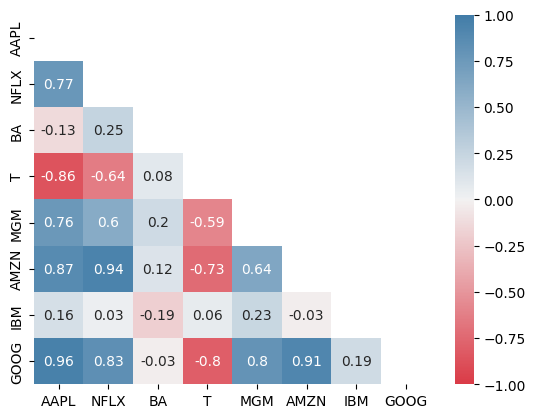

In [ ]:
import seaborn as sns

fig = sns.heatmap(correlation_matrix, annot=True, vmax=1,vmin=-1, mask = mask, cmap = cap)
fig.get_figure().savefig('corr.png', transparent=True)


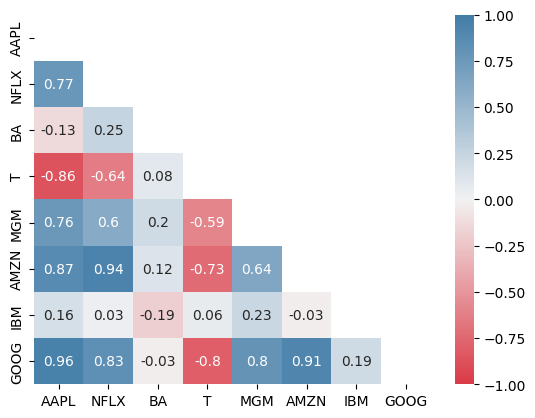

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Create heatmap with transparent face and edge colors
fig = sns.heatmap(correlation_matrix, annot=True, vmax=1, vmin=-1, mask=mask, cmap=cap)

# Set transparent background
fig.figure.patch.set_facecolor('none')  # Figure background
fig.set_facecolor('none')  # Axes background

# Save the figure with transparent background
fig.get_figure().savefig('corr.png', transparent=True)


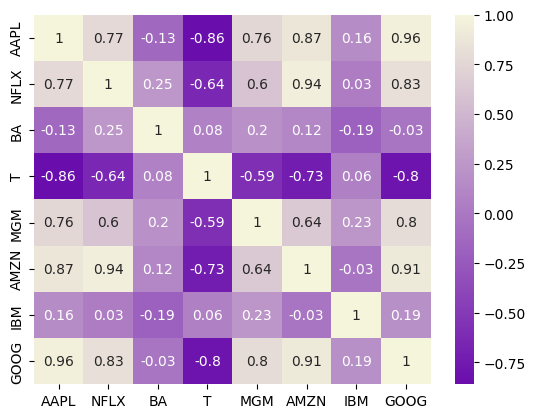

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define a custom purple-to-beige colormap
purple_beige_cmap = LinearSegmentedColormap.from_list("purple_beige", ["#6A0DAD", "#F5F5DC"])

# Create a figure and axis
fig, ax = plt.subplots()

# Set the background of the figure to transparent
fig.patch.set_alpha(0)

# Create heatmap with the custom colormap
sns.heatmap(correlation_matrix, annot=True, cmap=purple_beige_cmap, ax=ax)

# Save the figure with a transparent background
fig.savefig('corr.png', transparent=True)


AttributeError: 'Axes' object has no attribute 'savefig'

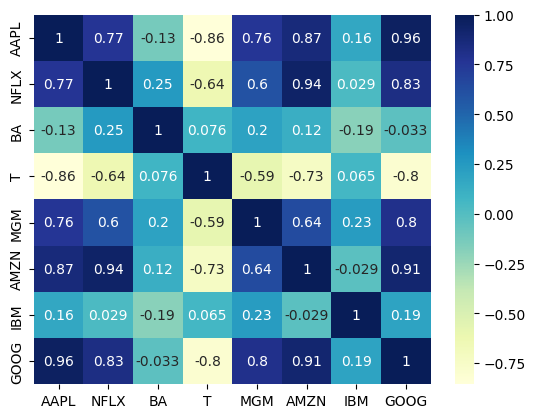

In [ ]:
import seaborn as sns

fig = sns.heatmap(correlation_matrix,annot=True,cmap='YlGnBu')
fig.savefig('corr.png',transparent=True)

<Axes: >

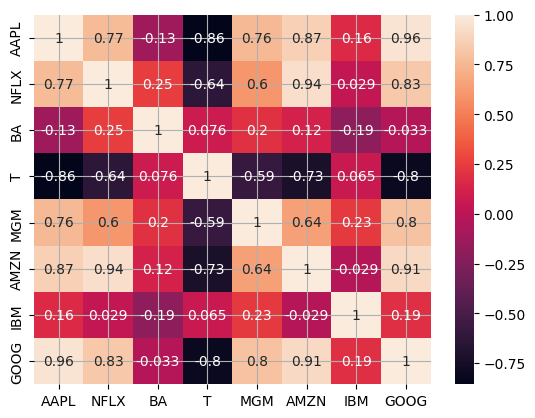

In [ ]:
fig = sns.heatmap(correlation_matrix,annot=True)

In [ ]:
import plotly.figure_factory as ff

# Calculate the correlation matrix of stock returns
correlation_matrix = normalized_data[[f'{stock}_Return' for stock in stocks]].corr()

# Create an interactive correlation heatmap
fig = ff.create_annotated_heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns.tolist(),
    y=correlation_matrix.index.tolist(),
    colorscale='Viridis',
    showscale=True
)

fig.update_layout(
    title='Correlation Heatmap of Stock Returns',
    xaxis_title='Stocks',
    yaxis_title='Stocks'
)
fig.show()


In [ ]:
# Interactive time series comparison with range slider
time_series_fig = px.line(
    data, x='DATE', y=[f'{stock}_Return' for stock in stocks],
    title="Stock Returns Over Time"
)

# Add range slider for zooming in/out
time_series_fig.update_xaxes(rangeslider_visible=True)
time_series_fig.update_layout(template='plotly_dark')
time_series_fig.show()


ValueError: All arguments should have the same length. The length of argument `y` is 4, whereas the length of  previously-processed arguments ['DATE'] is 3651

In [ ]:
# Create an interactive bubble chart comparing CAPM vs Avg returns
bubble_fig = px.scatter(
    stock_selection_df, x='CAPM_Expected_Return', y='Avg_Stock_Return',
    size=stock_selection_df['Avg_Stock_Return'], color='Stock',
    title='CAPM Expected Return vs. Average Return (Bubble Size = Avg Return)',
    labels={'CAPM_Expected_Return': 'CAPM Expected Return', 'Avg_Stock_Return': 'Average Return'}
)

bubble_fig.update_layout(template='plotly_dark')
bubble_fig.show()


In [ ]:
portfolio_fig = px.bar(
    stock_selection_df, x='Stock', y=['Beta', 'CAPM_Expected_Return', 'Avg_Stock_Return'],
    title='Portfolio Beta and Return Analysis',
    barmode='group',
    labels={'value': 'Value'}
)

portfolio_fig.update_layout(template='plotly_dark')
portfolio_fig.show()


Visualizing Predictions
9.1. Plotting Actual vs Predicted Values

In [ ]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')  # Diagonal line
plt.title('Actual vs Predicted Returns')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.grid()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1000x600 with 0 Axes>